In [1]:
import os
import time

import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
import torch
from vidgear.gears import WriteGear
import pickle

from dotenv import load_dotenv

from koger_detection.obj_det.mydatasets import VideoDataset

/home/koger/environments/orthocounting/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/koger/environments/orthocounting/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
load_dotenv()

True

In [4]:
camera_name = "cam09-trail_outflow"
date = "2025-08-07"
video_folder = os.environ.get("VIDEO_FOLDER")

outputs_folder = os.path.join(video_folder, "processing", "trail-2025-08-07")

box_files = sorted(glob.glob(os.path.join(outputs_folder, "*-boxes.npz")))
score_files = sorted(glob.glob(os.path.join(outputs_folder, "*-scores.npz")))
label_files = sorted(glob.glob(os.path.join(outputs_folder, "*-labels.npz")))

video_files = sorted(glob.glob(os.path.join(video_folder, camera_name, "Mp4Record", date,  "RecM0A*.mp4")))

print(len(box_files), len(score_files), len(label_files), len(video_files))


407 407 407 407


In [5]:
from yolox.tracker.byte_tracker import BYTETracker

In [26]:
class BearArguments:
    def __init__(self):
        self.track_thresh = 0.6
        self.track_buffer = 30
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 15
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

bear_args = BearArguments()

class SalmonArguments:
    def __init__(self):
        self.track_thresh = 0.85 # bizarelly .1 is added to this by BYTETracker, so set this to .1 less than the desired threshold
        self.track_buffer = 5
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 15
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

salmon_args = SalmonArguments()

In [27]:

class_to_track = 1 # 1 is bear, 3 is salmon
frame_num = 0
for clip_ind, (box_file, score_file, label_file) in enumerate(zip(box_files, score_files, label_files)):

    tracks = {}
    tracker = BYTETracker(bear_args)

    if clip_ind % 5 == 0:
        print(f"Processing file {clip_ind}/{len(box_files)-1}")
    z_boxes = np.load(box_file)
    z_scores = np.load(score_file)
    z_labels = np.load(label_file)

    for boxes_key, scores_key, labels_key in zip(z_boxes, z_scores, z_labels):
        dets = np.concatenate([z_boxes[boxes_key], 
                            z_scores[scores_key][:, np.newaxis], 
                            z_scores[scores_key][:, np.newaxis],
                            z_labels[labels_key][:, np.newaxis]
                            ], 
                            axis=1)
        dets = dets[dets[:,-1]==class_to_track]
        online_targets = tracker.update(torch.from_numpy(dets), [1440, 2560], [1440, 2560])

        for strack in online_targets:
            if strack.is_activated:
                track_id = strack.track_id
                if track_id not in tracks:
                    tracks[track_id] = {}
                tracks[track_id][strack.frame_id] = strack.tlwh

    with open(os.path.join(outputs_folder, f'{date}-tracks-class-{class_to_track}-clip-{clip_ind:04d}.pkl'), 'wb') as outp:
        pickle.dump(tracks, outp, pickle.HIGHEST_PROTOCOL)

Processing file 0/406
Processing file 5/406
Processing file 10/406
Processing file 15/406
Processing file 20/406
Processing file 25/406
Processing file 30/406
Processing file 35/406
Processing file 40/406
Processing file 45/406
Processing file 50/406
Processing file 55/406
Processing file 60/406
Processing file 65/406
Processing file 70/406
Processing file 75/406
Processing file 80/406
Processing file 85/406
Processing file 90/406
Processing file 95/406
Processing file 100/406
Processing file 105/406
Processing file 110/406
Processing file 115/406
Processing file 120/406
Processing file 125/406
Processing file 130/406
Processing file 135/406
Processing file 140/406
Processing file 145/406
Processing file 150/406
Processing file 155/406
Processing file 160/406
Processing file 165/406
Processing file 170/406
Processing file 175/406
Processing file 180/406
Processing file 185/406
Processing file 190/406
Processing file 195/406
Processing file 200/406
Processing file 205/406
Processing fil

In [28]:
track_files = sorted(glob.glob(os.path.join(outputs_folder, f'{date}-tracks-class-{class_to_track}-clip-*.pkl')))
print(len(track_files))

407


In [29]:
box_files[np.argmax(track_counts)]

'/mnt/f/pedrobay_2025/mounted-cameras/processing/trail-2025-08-07/RecM0A_DST20250807_165659_170150_0_531E8300000000_4AA2F93-boxes.npz'

In [32]:
salmon_track_counts = []

track_files = sorted(glob.glob(os.path.join(outputs_folder, f'{date}-tracks-class-{3}-clip-*.pkl')))

for track_file in track_files:
    with open(track_file, 'rb') as inp:
        tracks = pickle.load(inp)
        count = 0
        for key, val in tracks.items():
            if len(val) > 10:
                count += 1
        salmon_track_counts.append(count)

bear_track_counts = []

track_files = sorted(glob.glob(os.path.join(outputs_folder, f'{date}-tracks-class-{1}-clip-*.pkl')))

for track_file in track_files:
    with open(track_file, 'rb') as inp:
        tracks = pickle.load(inp)
        count = 0
        for key, val in tracks.items():
            if len(val) > 10:
                count += 1
        bear_track_counts.append(count)

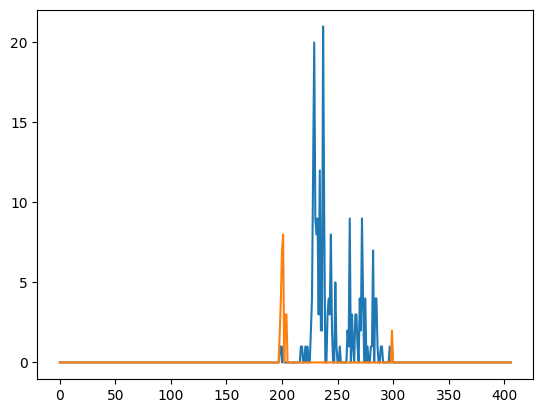

In [39]:
plt.plot(salmon_track_counts[:])
plt.plot(bear_track_counts[:])

In [34]:
np.where(np.array(bear_track_counts) > 0)[0]

array([198, 199, 200, 201, 203, 204, 299])

In [37]:
box_files[299]

'/mnt/f/pedrobay_2025/mounted-cameras/processing/trail-2025-08-07/RecM0A_DST20250807_193432_193632_0_531E8300000000_1F05386-boxes.npz'

(array([355.,   0.,  20.,   0.,   6.,   0.,   0.,   6.,   0.,   7.,   0.,
          1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   2.,   0.,   5.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   1.]),
 array([ 0.  ,  0.42,  0.84,  1.26,  1.68,  2.1 ,  2.52,  2.94,  3.36,
         3.78,  4.2 ,  4.62,  5.04,  5.46,  5.88,  6.3 ,  6.72,  7.14,
         7.56,  7.98,  8.4 ,  8.82,  9.24,  9.66, 10.08, 10.5 , 10.92,
        11.34, 11.76, 12.18, 12.6 , 13.02, 13.44, 13.86, 14.28, 14.7 ,
        15.12, 15.54, 15.96, 16.38, 16.8 , 17.22, 17.64, 18.06, 18.48,
        18.9 , 19.32, 19.74, 20.16, 20.58, 21.  ]),
 <BarContainer object of 50 artists>)

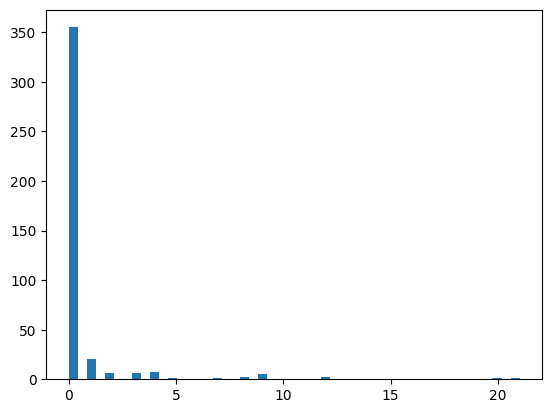

In [25]:
plt.hist(track_counts, bins=50)

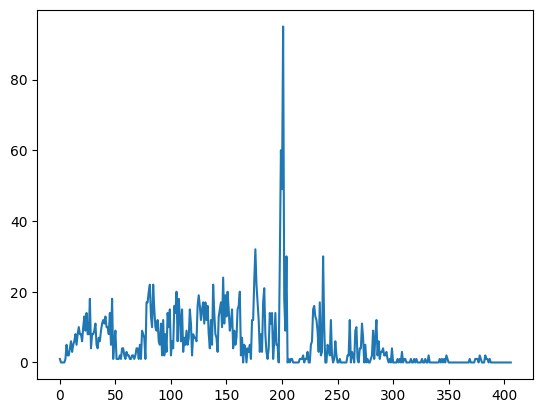

In [16]:
plt.plot(track_counts)

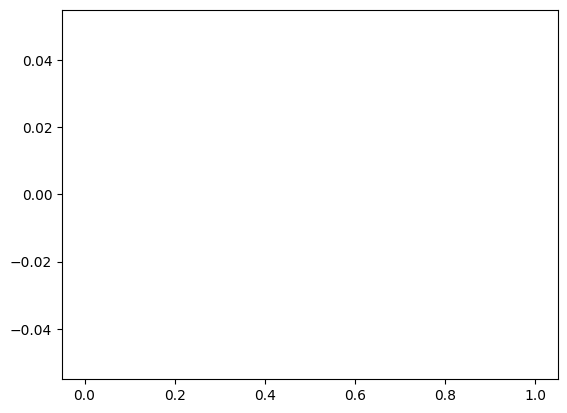

In [11]:
tracks_length = []
for track_id, track in tracks.items():
    if len(track) > 10:
        tracks_length.append(len(track))
_ = plt.hist(tracks_length, bins=100)

In [85]:
print(len(tracks))

30


In [16]:
import matplotlib as mpl

In [17]:
cmap = mpl.colormaps['tab20']
colors = [(np.array(c) * 255) for c in cmap.colors]

In [23]:
start_clip_ind = 237
ds = VideoDataset(video_files[start_clip_ind])
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)
video_name = os.path.basename(video_files[start_clip_ind]).split(".")[0]
out_name = f"{video_name}-track-new-model2.mp4"

output_params = {"-input_framerate": 30,
                "-pix_fmt": "yuv420p"}
out_folder = os.path.join(video_folder, "temp-media")
writer = WriteGear(output=os.path.join(out_folder, out_name),
                **output_params) 

track_file = track_files[start_clip_ind]
with open(track_file, 'rb') as inp:
    tracks = pickle.load(inp)

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, f in enumerate(data_loader):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 1000 == 0:
        print(f"Frame number {ind} processed.")

    frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons

    for track_id, track in tracks.items():
        if ind in track:
            box = track[ind]
            x = box[0] + int(box[2] / 2)
            y = box[1] + int(box[3] / 2)
            color = colors[track_id % len(colors)]
            cv2.circle(frame, [int(x), int(y)], 8, (int(color[0]), int(color[1]), int(color[2])), -1)
            cv2.putText(frame, str(track_id), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    if frame is not None:
        writer.write(frame, rgb_mode=True)
    else:
        print("skipping.")

    if ind > 20000:
        break
ds.stop()   

writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

10:55:26 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Frame number 0 processed.
Frame number 1000 processed.
Frame number 2000 processed.
Frame number 3000 processed.
Frame number 4000 processed.
Empty frame. Ending stream.
FileVideoStream stopped.
96.57423305511475 fps: 45.26051993087512 4371 frames processed.


In [22]:
track_file

'/mnt/f/pedrobay_2025/mounted-cameras/processing/trail-2025-08-07/2025-08-07-tracks-class-3-clip-0406.pkl'

In [25]:
scores = []
labels = []
video_inds = []

for i, (box_file, score_file, label_file) in enumerate(zip(box_files, score_files, label_files)):

    if i % 50 == 0:
        print(f"Processing file {i+1}/{len(box_files)}")
    # z_boxes = np.load(box_file)
    z_scores = np.load(score_file)
    z_labels = np.load(label_file)

    for key in z_scores.files:
        scores.append(z_scores[key])
        video_inds.append(i)
    for key in z_labels.files:
        labels.append(z_labels[key])

Processing file 1/407
Processing file 51/407
Processing file 101/407
Processing file 151/407
Processing file 201/407
Processing file 251/407
Processing file 301/407
Processing file 351/407
Processing file 401/407


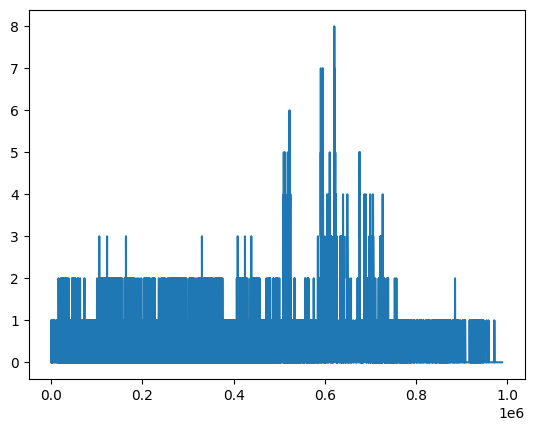

In [26]:
object_counts = []

for frame_scores, frame_labels in zip(scores, labels):
    object_counts.append(np.sum(frame_scores > 0.95))
    
plt.plot(object_counts)

In [29]:
object_counts.shape, video_inds.shape

((988067,), (988067,))

In [46]:
object_counts = np.array(object_counts)
video_inds = np.array(video_inds)

print(np.unique(video_inds[object_counts ==4]))
np.unique(video_inds[object_counts ==np.max(object_counts)])
np.max(object_counts)


[198 199 200 201 202 204 228 229 231 232 234 237 238 244 248 261 266 267
 272 275 285]


8

In [47]:
video_ind = 237
video_name = os.path.basename(video_files[video_ind]).split(".")[0]
video_file = video_files[video_ind]


box_file = box_files[video_ind]
score_file = score_files[video_ind]
label_file = label_files[video_ind]

z_boxes = np.load(box_file)
z_scores = np.load(score_file)
z_labels = np.load(label_file)

classes = {1: "bear", 2: "dead-salmon", 3: "salmon"}

In [48]:
score_threshold = 0.95

ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)
out_name = f"{video_name}-boxes-threshold-{score_threshold}.mp4"

colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]

save_folder = os.path.join(video_folder, "temp-media")
os.makedirs(save_folder, exist_ok=True)

output_params = {"-input_framerate": 30,
                "-pix_fmt": "yuv420p"}
writer = WriteGear(output=os.path.join(save_folder, out_name),
                **output_params) 

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, preds in enumerate(zip(data_loader, z_boxes, z_scores, z_labels)):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 1000 == 0:
        print(f"Frame number {ind} processed.")

    f, boxes_key, scores_keys, labels_key = preds
    frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons

    boxes = z_boxes[boxes_key]
    scores = z_scores[scores_keys]
    labels = z_labels[labels_key]
    for box, score, label in zip(boxes, scores, labels):
        if score < score_threshold:
            continue
        color = colors[label % len(colors)]
        cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), color, 2)
        cv2.putText(frame, f"{score:.2f} - {classes[label]}", (int(box[0]), int(box[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    if frame is not None:
        writer.write(frame, rgb_mode=True)
    else:
        print("skipping.")

    if ind > 20000:
        break
ds.stop()   

writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

12:02:26 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Frame number 0 processed.
Frame number 1000 processed.
Frame number 2000 processed.
Frame number 3000 processed.
Frame number 4000 processed.
Empty frame. Ending stream.
FileVideoStream stopped.
98.73114204406738 fps: 44.27174556584244 4371 frames processed.


In [16]:
for key in z_scores:
    print(z_scores[key])

[0.3435209  0.33591104 0.2805941  0.23396716 0.20600696 0.2059674
 0.19867422 0.19196    0.19033103 0.12801534 0.11908598 0.11200415
 0.11075924 0.07723104 0.05530552]
[0.5348858  0.49469352 0.33687568 0.30856258 0.30299783 0.17402202
 0.13782367 0.12612744 0.12116891 0.12094672 0.10690299 0.08437984
 0.08366992 0.08237756 0.07790376 0.07355659 0.06595632 0.06563827
 0.064031   0.06277589 0.05885628 0.05519181 0.05405729 0.05355898
 0.05329692 0.05149824]
[0.10589433 0.06167539]
[0.89494693 0.5799506  0.32979292 0.17218304 0.14697511 0.10234345
 0.09411975 0.09269117 0.09206358 0.06463696 0.06367459 0.06289721
 0.05048655 0.05027675]
[0.6842163  0.5430973  0.52015257 0.15946636 0.09935369 0.06782814
 0.06764732 0.06720648 0.06188561 0.05683845 0.0533479  0.05325874
 0.05004102]
[0.8123346  0.3527991  0.32754308 0.30882737 0.22054881 0.18484032
 0.18148012 0.1805848  0.10558626 0.0991858  0.09634995 0.08766195
 0.08357516 0.08283383 0.06534848 0.06504531 0.06382146 0.06255148
 0.0590298